In [1]:
!pip install opencv-python together

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.4/86.4 kB 3.2 MB/s eta 0:00:00
  Using cached eval_type_backport-0.2.2-py3-none-any.whl.metadata (2.2 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.6/90.6 kB 5.0 MB/s eta 0:00:00
  Using cached aiohappyeyeballs-2.6.1-py3-none-any.whl.metadata (5.9 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.1/75.1 kB 8.0 MB/s eta 0:00:00
  Using cached mypy_extensions-1.1.0-py3-none-any.whl.metadata (1.1 kB)
  Using cached annotated_types-0.7.0-py3-none-any.whl.metadata (15 kB)
  Using cached shellingham-1.5.4-py2.py3-none-any.whl.metadata (3.5 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 120.3/120.3 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 493.5/493.5 kB 8.5 MB/s eta 0:00:0010.4 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 15.6 MB/s eta 0:00:00m eta 0:00:010:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 7.9 MB/s eta 0:00:0018.6 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━

In [ ]:
TOGETHER_API_KEY="tgp_v1_LkTSvMqP2UGhGF-DI_NRADfI19Ff7JrD15K17VvO3Bs"

In [36]:
import os
import json
import math
import base64
import argparse
from typing import List, Dict, Any, Optional, Tuple

import cv2  # pip install opencv-python
from together import Together  # pip install together
from pydantic import BaseModel, Field

Video → 1 FPS frames

In [25]:
def extract_frames_at_fps(
    video_path: str,
    out_dir: str,
    start_time_s: float,
    duration_s: float,
    sample_fps: float,
    jpeg_quality: int = 92,
) -> List[Dict[str, Any]]:
    """
    Extract frames at `sample_fps` starting from `start_time_s` for `duration_s` seconds,
    by timestamp seeking using CAP_PROP_POS_MSEC.

    Args:
      video_path: path to input video
      out_dir: folder to write JPEG frames
      start_time_s: start time in seconds (>= 0)
      duration_s: duration from start time in seconds (> 0)
      sample_fps: sampling rate in frames per second (> 0)
      jpeg_quality: JPEG quality (1-100)

    Returns:
      List of dicts: [{"t": absolute_time_seconds, "path": frame_path}, ...]
    """
    if start_time_s < 0:
        raise ValueError("start_time_s must be >= 0")
    if duration_s <= 0:
        raise ValueError("duration_s must be > 0")
    if sample_fps <= 0:
        raise ValueError("sample_fps must be > 0")
    if not (1 <= jpeg_quality <= 100):
        raise ValueError("jpeg_quality must be between 1 and 100")

    os.makedirs(out_dir, exist_ok=True)

    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        raise RuntimeError(f"Could not open video: {video_path}")

    dt = 1.0 / float(sample_fps)
    end_time_s = start_time_s + duration_s

    frames: List[Dict[str, Any]] = []
    idx = 0

    # iterate in fixed steps to avoid drift; compute t from idx each time
    # Use a small epsilon to include the last sample when it lands exactly on end_time_s
    eps = 1e-9
    t = start_time_s

    while t < end_time_s + eps:
        cap.set(cv2.CAP_PROP_POS_MSEC, t * 1000.0)
        ok, frame = cap.read()
        if not ok or frame is None:
            break

        frame_path = os.path.join(out_dir, f"frame_{idx:06d}_t{t:.3f}.jpg")
        cv2.imwrite(frame_path, frame, [int(cv2.IMWRITE_JPEG_QUALITY), int(jpeg_quality)])

        frames.append({"t": float(round(t, 3)), "path": frame_path})

        idx += 1
        # compute next timestamp deterministically to minimize floating drift
        t = start_time_s + idx * dt

    cap.release()
    return frames

frames = extract_frames_at_fps("./fighting/inmate_fight.mp4", 
    "fighting/frames_output", 
    start_time_s=3.0, 
    duration_s=7.0, 
    sample_fps=10.0, 
    jpeg_quality=92
)

In [14]:
def encode_image_to_data_url(image_path: str) -> str:
    """
    Together vision models accept image_url as a normal URL OR a data URL with base64.
    """
    ext = os.path.splitext(image_path)[1].lower()
    mime = "image/jpeg" if ext in [".jpg", ".jpeg"] else "image/png"

    with open(image_path, "rb") as f:
        b64 = base64.b64encode(f.read()).decode("utf-8")
    return f"data:{mime};base64,{b64}"

In [15]:
class FightDetectionResult(BaseModel):
    fight_detected: bool = Field(description="True if a physical fight is occurring in the provided frames.")
    confidence: float = Field(description="Confidence from 0.0 to 1.0.", ge=0.0, le=1.0)
    fight_start_time_seconds: Optional[float] = Field(
        description="Absolute timestamp in seconds for when the fight first starts within the provided frames. Null if none."
    )
    short_description: str = Field(description="Very short summary (1 sentence).")
    long_description: str = Field(description="More detailed description (2-6 sentences).")
    key_evidence: List[str] = Field(
        description="Up to 6 bullet-like evidence snippets tied to timestamps and actions.",
        max_length=6,
    )

In [16]:
schema = FightDetectionResult.model_json_schema()
instruction = (
    "You are a safety video analyst. The user provides a sequence of frames with explicit timestamps.\n"
    "Your task: determine whether a PHYSICAL FIGHT is happening (punching, kicking, grappling, hitting, violent struggle).\n"
    "If it is NOT clearly a fight, set fight_detected=false with low confidence.\n"
    "If fight_detected=true, estimate the earliest timestamp (in seconds) when the fight starts.\n\n"
    "IMPORTANT:\n"
    "- Use the timestamps (<... seconds>) to reason about temporal order.\n"
    "- Only answer in JSON and follow this schema exactly:\n"
    f"{json.dumps(schema)}"
)

In [26]:
def build_interleaved_timestamp_image_content(
    frames_window: List[Dict[str, Any]],
    instruction_text: str,
) -> List[Dict[str, Any]]:
    """
    Produces:
      [
        {"type":"text","text":"<0.0 seconds>"},
        {"type":"image_url","image_url":{"url":"data:..."}},
        {"type":"text","text":"<0.333 seconds>"},
        {"type":"image_url","image_url":{"url":"data:..."}},
        ...
        {"type":"text","text":"FINAL INSTRUCTION ..."}
      ]
    """
    content: List[Dict[str, Any]] = []

    for f in frames_window:
        t = float(f["t"])
        content.append({"type": "text", "text": f"<{t:.3f} seconds>"})
        content.append({"type": "image_url", "image_url": {"url": encode_image_to_data_url(f["path"])}})

    content.append({"type": "text", "text": instruction_text})
    return content

prompt = build_interleaved_timestamp_image_content(
    frames_window=frames,
    instruction_text=instruction,
)

print("Prompt content length:", len(prompt))

Prompt content length: 143


In [41]:
client = Together(api_key=TOGETHER_API_KEY)

resp = client.chat.completions.create(
    model="google/gemma-3n-E4B-it",
    messages=[{"role": "user", "content": prompt}],
    temperature=0.0,
    max_tokens=600,
    response_format={"type": "json_schema", "schema": schema},
)

In [42]:
raw = (resp.choices[0].message.content or "").strip()
try:
    out = json.loads(raw)
except json.JSONDecodeError:
    # salvage JSON if wrapped
    s = raw.find("{")
    e = raw.rfind("}")
    if s >= 0 and e > s:
        out = json.loads(raw[s : e + 1])
    else:
        raise RuntimeError(f"Model did not return valid JSON.\nRaw:\n{raw}")

validated = FightDetectionResult(**out).model_dump()
print("Validated output:")
print(json.dumps(validated, indent=2))

Validated output:
{
  "fight_detected": true,
  "confidence": 0.95,
  "fight_start_time_seconds": 0.0,
  "short_description": "The video shows a physical altercation occurring in a prison yard. Two individuals are actively fighting.",
  "long_description": "The video shows a physical altercation occurring in a prison yard. Two individuals are seen engaging in a physical fight, with one individual appearing to strike the other. The fight appears to be ongoing and involves physical contact. The fight starts at the beginning of the video.",
  "key_evidence": [
    "At approximately 0.0 seconds, two individuals are seen engaging in physical altercation.",
    "At approximately 0.0 seconds, one individual appears to strike the other.",
    "At approximately 0.0 seconds, the individuals are grappling with each other.",
    "At approximately 0.0 seconds, there is visible physical contact between the individuals.",
    "At approximately 0.0 seconds, the individuals are moving aggressively towa

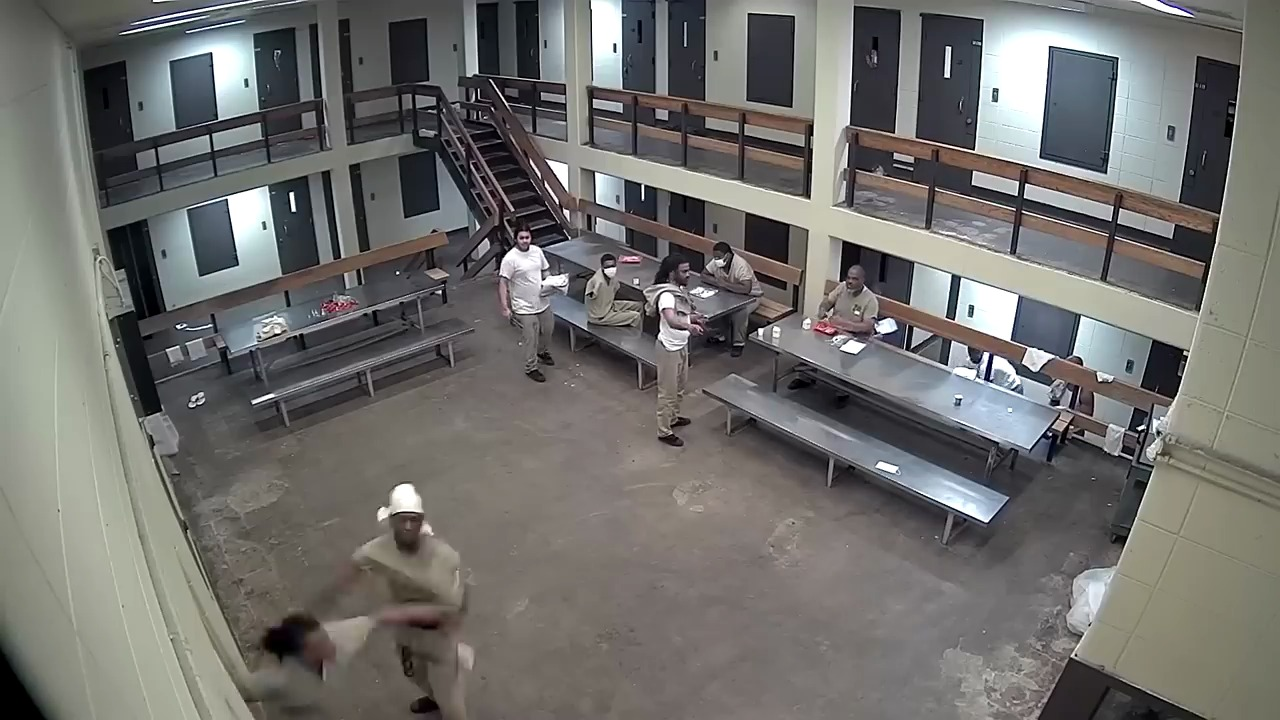

In [29]:
from IPython.display import Image, display

display(Image("fighting/frames_output/frame_000015_t4.500.jpg"))

([{'role': 'user',
   'content': [{'type': 'text',
     'text': 'Describe exactly what is visible in this frame. Mention where people are in the scene.'},
    {'type': 'image_url',
     'image_url': {'url': ''}}]}],)
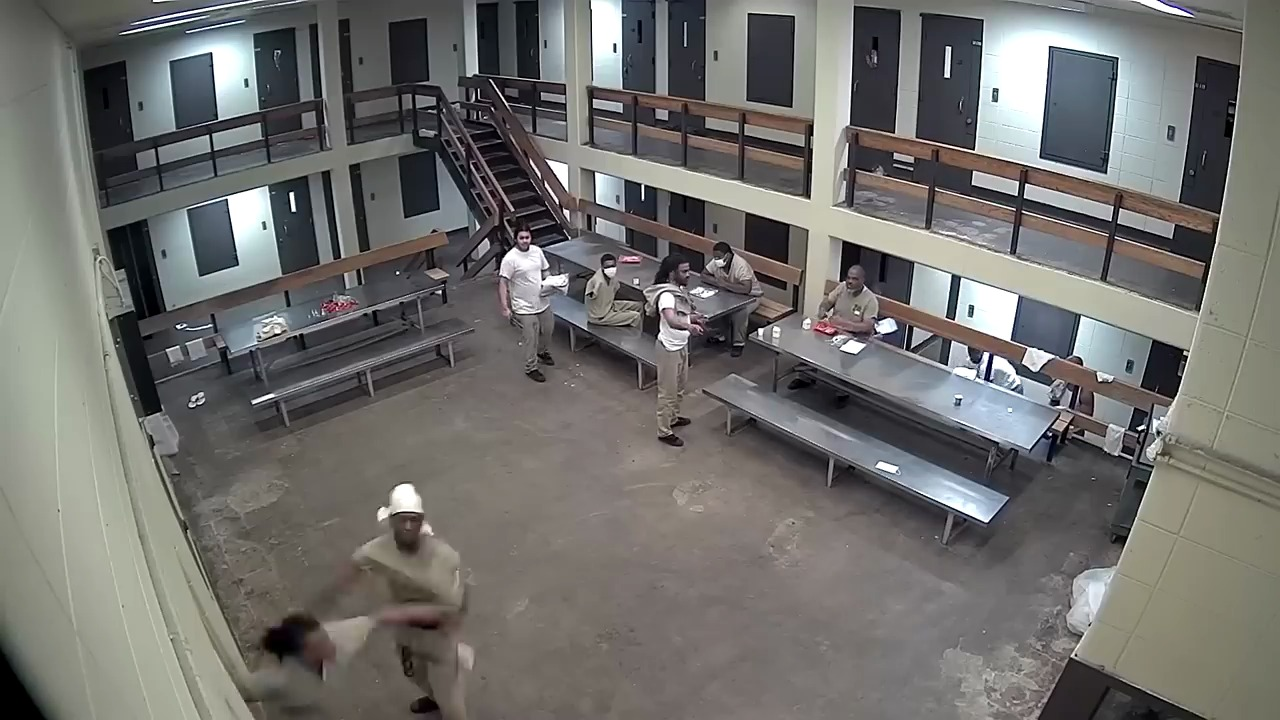

In [39]:
messages=[{
        "role": "user",
        "content": [
            {"type":"text","text":"Describe exactly what is visible in this frame. Mention where people are in the scene."},
            {"type":"image_url","image_url":{"url": encode_image_to_data_url("fighting/frames_output/frame_000015_t4.500.jpg")}}
        ]
    }],
messages

In [40]:
resp = client.chat.completions.create(
    model="google/gemma-3n-E4B-it",
    messages=[{
        "role": "user",
        "content": [
            {"type":"text","text":"Describe exactly what is visible in this frame. Mention where people are in the scene."},
            {"type":"image_url","image_url":{"url": encode_image_to_data_url("fighting/frames_output/frame_000015_t4.500.jpg")}}
        ]
    }],
    temperature=0.2,
    max_tokens=600,
)
print(resp.choices[0].message.content)


The frame shows a large, multi-level room that appears to be a prison or correctional facility common area. The room has a concrete floor and light-colored walls. There are multiple doors along the walls, likely leading to individual cells. 

**People in the scene:**

*   **In the foreground (lower left):** Two individuals are engaged in a physical altercation. One person is wearing a white skullcap and light-colored clothing, while the other is wearing a light-colored uniform and a white skullcap.
*   **On the ground floor (center):** Several people are seated at long metal tables. They are wearing light-colored uniforms and some are wearing face masks. They appear to be eating or conversing.
*   **On the upper level (various locations):** A few individuals are standing or sitting at tables on the upper level. They are also wearing light-colored uniforms.
*   **Near the stairs:** A person in a light-colored uniform is standing near a staircase that leads to the upper level.

The overa